# Simulation 
Here we test to see that our code works by injecting a noise at  with band-limited noise and see if we can recover the signal.

In [1]:
import numpy as np 
from matplotlib import pyplot as plt

In [2]:
import numpy as np

def knee_psd_timeseries(n, fs, f_knee=5.0, beta=1.0, rms=1.0, seed=None):
    """
    Real-valued time series with PSD:
      - flat (white) above f_knee
      - ~ 1/f^beta below f_knee
    beta=1 is classic 1/f; beta=2 is random-walk-ish.

    rms sets the final time-series RMS (after mean removal).
    """
    rng = np.random.default_rng(seed)
    freqs = np.fft.rfftfreq(n, d=1/fs)

    # complex white spectrum
    spec = rng.normal(size=freqs.size) + 1j * rng.normal(size=freqs.size)

    # amplitude shaping for desired PSD
    # PSD ~ |spec|^2 * shape^2  => choose shape ~ f^{-beta/2} below knee
    shape = np.ones_like(freqs)
    m = (freqs > 0) & (freqs < f_knee)
    shape[m] = (f_knee / freqs[m]) ** (beta / 2)

    # DC set to 0 (avoid huge low-f blow-up)
    shape[freqs == 0] = 0.0

    spec *= shape

    x = np.fft.irfft(spec, n=n)
    x -= np.mean(x)
    x *= (rms / (np.std(x) + 1e-12))
    return x

In [3]:
def variance_vs_frequency_series(x, coadds_list, frame_dt_s, ddof=1):
    """
    For each coadds, average x into blocks and compute Var(block_means).
    """
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "var": []}

    for n in coadds_list:
        Ntrim = (len(x) // n) * n
        if Ntrim < 2*n:
            continue
        xb = x[:Ntrim].reshape(-1, n).mean(axis=1)   # mean keeps units consistent
        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["var"].append(np.var(xb, ddof=ddof))

    return {k: np.array(v) for k, v in out.items()}

In [4]:
def variance_vs_frequency_chop_proxy(x, coadds_list, frame_dt_s, ddof=1):
    """
    For each coadds, compute block means then take successive differences and compute Var(diffs).

    
    """
    # Initialize output dictionary
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "var_diff": []}

    # Loop over each coadds value
    for n in coadds_list:
        # Trim x to a multiple of n
        Ntrim = (len(x) // n) * n
        if Ntrim < 3*n:   # need at least 3 blocks to get >=2 diffs
            continue
        # Groups n consecutive frames and computes their mean
        xb = x[:Ntrim].reshape(-1, n).mean(axis=1)

        # Computes successive differences (i.e. A - B subtraction)
        d = np.diff(xb)

        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["var_diff"].append(np.var(d, ddof=ddof))

    return {k: np.array(v) for k, v in out.items()}


In [5]:

# --- your function (unchanged) ---
def variance_vs_frequency_chop_proxy(x, coadds_list, frame_dt_s, method, ddof=1):
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "var_diff": []}
    for n in coadds_list:
        Ntrim = (len(x) // n) * n
        if Ntrim < 3*n:
            continue
        if method == "mean":
            xb = x[:Ntrim].reshape(-1, n).mean(axis=1)

        if method  == "sum": 
            xb = x[:Ntrim].reshape(-1, n).sum(axis=1)
        d = np.diff(xb)
        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["var_diff"].append(np.var(d, ddof=ddof))
    return {k: np.array(v) for k, v in out.items()}

# --- injection ---
# --- Modified injection function for multiple frequencies ---
def inject_sinusoid(nframes, frame_dt_s, A=1.0, f0=1.0, white_rms=0.0, offset=0.0, seed=0):
    """
    Inject one or more sinusoids into a time series with optional white noise.
    
    Parameters
    ----------
    nframes : int
        Number of frames in time series
    frame_dt_s : float
        Time between frames in seconds
    A : float or array-like
        Amplitude(s) of sinusoid(s). If array, must match length of f0
    f0 : float or array-like
        Frequency/frequencies in Hz
    white_rms : float
        RMS of white noise to add
    offset : float
        DC offset
    seed : int
        Random seed for noise generation
        
    Returns
    -------
    x : ndarray
        Time series with injected signal(s) and noise
    """
    t = np.arange(nframes) * frame_dt_s
    
    # Convert to arrays for consistent handling
    A = np.atleast_1d(A)
    f0 = np.atleast_1d(f0)
    
    if len(A) != len(f0):
        raise ValueError(f"A and f0 must have same length. Got A:{len(A)}, f0:{len(f0)}")
    
    # Build composite signal from all frequencies
    s = np.zeros(nframes)
    for amp, freq in zip(A, f0):
        s += amp * np.sin(2*np.pi*freq*t)
    
    # Add white noise
    rng = np.random.default_rng(seed)
    w = rng.normal(scale=white_rms, size=nframes)
    
    return offset + s + w

# --- analytic prediction for the sinusoid through (block-mean + diff) ---
def H_avg_sq(f, dt, n):
    x = np.pi * f * dt
    num = np.sin(n*x)
    den = n*np.sin(x)
    # limit as f->0 is 1
    if np.abs(den) < 1e-20:
        return 1.0
    return (num/den)**2

def H_diff_sq(f, dt, n):
    return 4.0 * np.sin(np.pi * f * (n*dt))**2

def predicted_var_for_sinusoid(A, f0, dt, n):
    # sinusoid has variance A^2/2; filtering scales power by |H|^2
    return (A**2 / 2.0) * H_avg_sq(f0, dt, n) * H_diff_sq(f0, dt, n)



In [6]:
nframes = 1600 
frame_dt_s = 0.011
cadds_list = np.arange(5, 251)

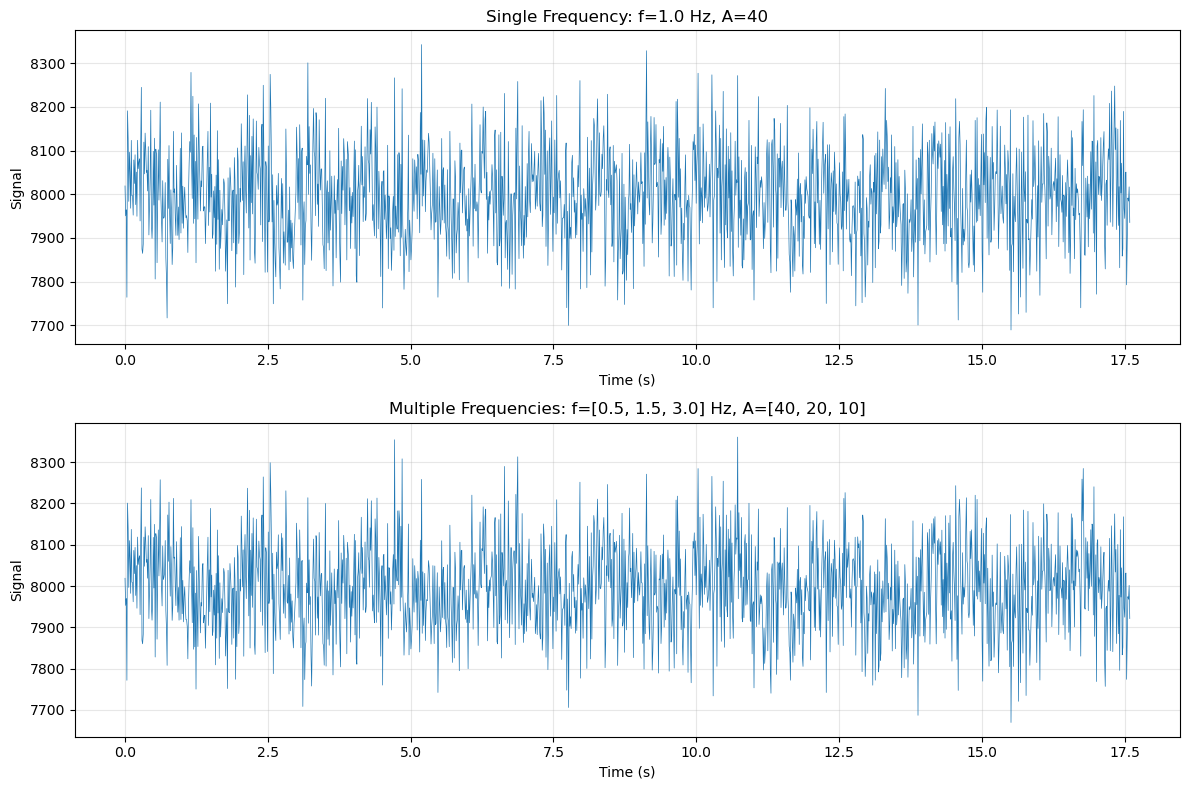

In [7]:
# Example 1: Single frequency (backward compatible)
x_single = inject_sinusoid(nframes, frame_dt_s, A=40.0, f0=1.0, white_rms=100.0, offset=8000.0, seed=2)

# Example 2: Multiple frequencies with different amplitudes
A_multi = [40.0, 20.0, 10.0]  # Different amplitudes
f0_multi = [0.5, 1.5, 3.0]     # Different frequencies (Hz)
x_multi = inject_sinusoid(nframes, frame_dt_s, A=A_multi, f0=f0_multi, white_rms=100.0, offset=8000.0, seed=2)

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Single frequency
axes[0].plot(np.arange(nframes) * frame_dt_s, x_single, lw=0.5)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Signal')
axes[0].set_title('Single Frequency: f=1.0 Hz, A=40')
axes[0].grid(True, alpha=0.3)

# Multiple frequencies
axes[1].plot(np.arange(nframes) * frame_dt_s, x_multi, lw=0.5)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Signal')
axes[1].set_title('Multiple Frequencies: f=[0.5, 1.5, 3.0] Hz, A=[40, 20, 10]')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

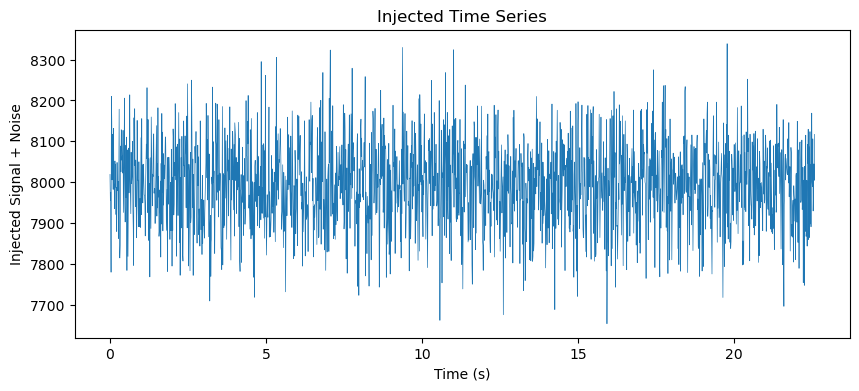

In [8]:
# --- run the test ---
frame_dt_s = 0.0113        # <-- set to your frame time
fs = 1.0 / frame_dt_s
nframes = 2000           # long enough to be stable at low f
coadds_list = np.unique(np.round(np.logspace(0, 2.6, 50)).astype(int))  # 1..1000-ish

A = 40.0                   # injected sinusoid amplitude (in same units as x)
f0 = 3           # injected frequency (Hz) - pick below your knee
white_rms = 100.0           # optional noise floor

x = inject_sinusoid(nframes, frame_dt_s, A=A, f0=f0, white_rms=white_rms, offset=8000.0, seed=2)
# plot the injected time series
plt.figure(figsize=(10, 4))
plt.plot(np.arange(nframes) * frame_dt_s, x, lw=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Injected Signal + Noise')
plt.title('Injected Time Series')
plt.show()


In [9]:
out = variance_vs_frequency_chop_proxy(x_multi, coadds_list, frame_dt_s, method="sum", ddof=1)

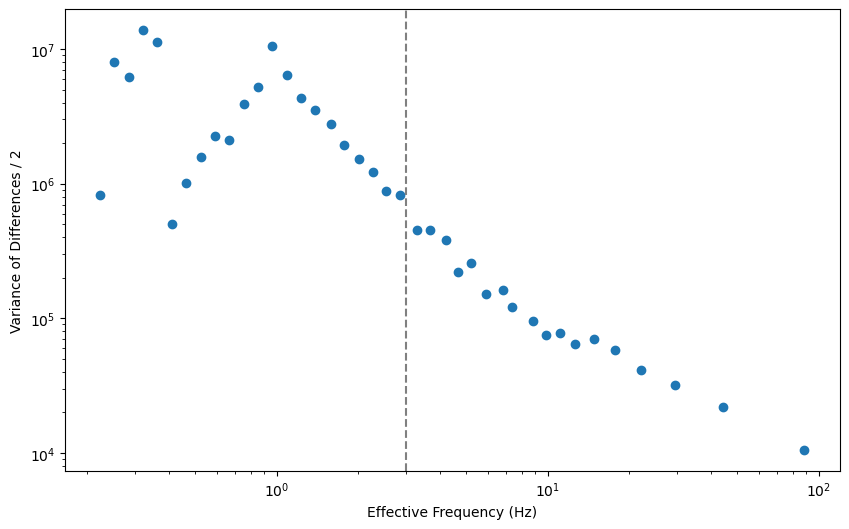

In [10]:
# plot the results 
plt.figure(figsize=(10, 6))
plt.plot(out['f_eff_hz'], out['var_diff']/2, 'o', label='Measured Var(diff)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Effective Frequency (Hz)')
plt.ylabel('Variance of Differences / 2')

# overplot analytic prediction 
plt.axvline(f0, color='gray', ls='--', label='Injected Frequency')


Text(0.5, 1.0, 'Variance vs Frequency with Injected Sinusoid (1000 random realizations)')

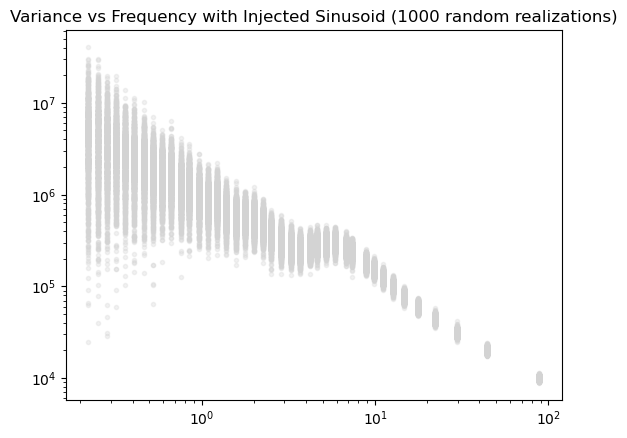

In [11]:
# now run 100 realizations of inject sinusoid and plot the results 
for seed in range(1000):
    x = inject_sinusoid(nframes, frame_dt_s, A=A, f0=f0, white_rms=white_rms, offset=8000.0, seed=seed)
    out = variance_vs_frequency_chop_proxy(x, coadds_list, frame_dt_s, method="sum", ddof=1)
    plt.loglog(out['f_eff_hz'], out['var_diff']/2, '.', color='lightgray', alpha=0.3)
    # make a violin plot of the predicted variance
    

# Plot injected freuquency line and labels
plt.title('Variance vs Frequency with Injected Sinusoid (1000 random realizations)')


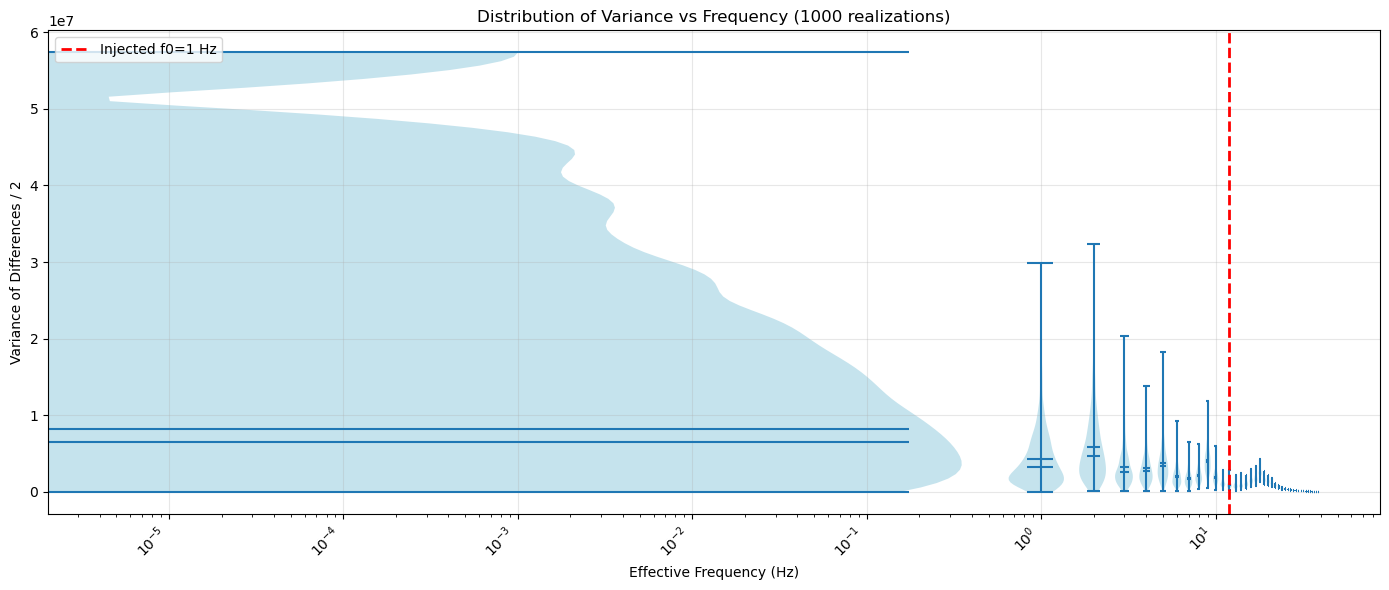


Statistics at f_eff ≈ 0.962 Hz (closest to f0=1 Hz):
  Mean variance: 960315.82
  Median variance: 915582.10
  Std deviation: 372696.61


In [61]:
# Collect all variance measurements organized by frequency
from collections import defaultdict

variance_by_freq = defaultdict(list)

for seed in range(1000):
    x = inject_sinusoid(nframes, frame_dt_s, A=A, f0=f0, white_rms=white_rms, offset=8000.0, seed=seed)
    out = variance_vs_frequency_chop_proxy(x, coadds_list, frame_dt_s, method="sum", ddof=1)
    
    # Store variances by their effective frequency
    for freq, var in zip(out['f_eff_hz'], out['var_diff']/2):
        variance_by_freq[freq].append(var)

# Convert to arrays for plotting
freqs = sorted(variance_by_freq.keys())
var_distributions = [variance_by_freq[f] for f in freqs]

# Create violin plot
fig, ax = plt.subplots(figsize=(14, 6))

# Create violin plot
parts = ax.violinplot(var_distributions, positions=range(len(freqs)), 
                       widths=0.7, showmeans=True, showmedians=True)

# Customize violin colors
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_alpha(0.7)

ax.set_xticks(range(len(freqs)))
ax.set_xticklabels([f'{f:.2f}' for f in freqs], rotation=45, ha='right')
ax.set_xlabel('Effective Frequency (Hz)')
plt.xscale('log')
ax.set_ylabel('Variance of Differences / 2')
ax.set_title('Distribution of Variance vs Frequency (1000 realizations)')
ax.grid(True, alpha=0.3)

# Add vertical line at injected frequency
f0_idx = np.argmin(np.abs(np.array(freqs) - f0))
ax.axvline(f0_idx, color='red', ls='--', linewidth=2, label=f'Injected f0={f0} Hz')
ax.legend()

plt.tight_layout()
plt.show()

# Also print statistics at the injected frequency
closest_freq = freqs[f0_idx]
print(f"\nStatistics at f_eff ≈ {closest_freq:.3f} Hz (closest to f0={f0} Hz):")
print(f"  Mean variance: {np.mean(variance_by_freq[closest_freq]):.2f}")
print(f"  Median variance: {np.median(variance_by_freq[closest_freq]):.2f}")
print(f"  Std deviation: {np.std(variance_by_freq[closest_freq]):.2f}")

Now try  and run it for what happens when when you sum instead of mean

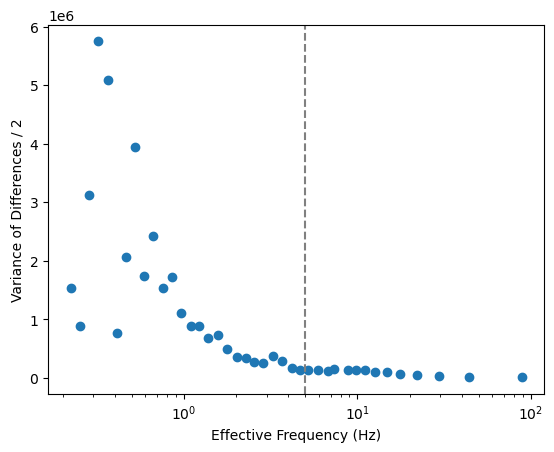

In [46]:
out_sum = variance_vs_frequency_chop_proxy(x, coadds_list, frame_dt_s, method="sum", ddof=1)
plt.plot(out_sum['f_eff_hz'], out_sum['var_diff']/2, 'o', label='Measured Var(diff) sum')
plt.xscale('log')
plt.xlabel('Effective Frequency (Hz)')
plt.ylabel('Variance of Differences / 2')   

# over pltot analytic prediction for both mean and sum
plt.axvline(f0, color='gray', ls='--', label='Injected Frequency')

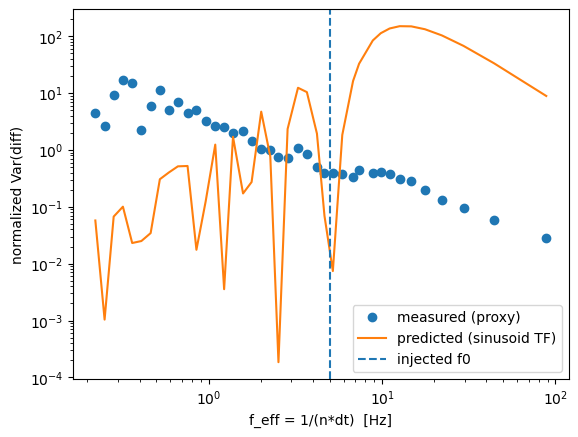

In [47]:
# prediction (up to finite-sample bias; shape is what matters)
v_pred = np.array([predicted_var_for_sinusoid(A, f0, frame_dt_s, n) for n in out["coadds"]])

# normalize both so you compare shapes cleanly
v_meas = out["var_diff"] / np.median(out["var_diff"])
v_pred = v_pred / np.median(v_pred)

plt.figure()
plt.loglog(out["f_eff_hz"], v_meas, "o", label="measured (proxy)")
plt.loglog(out["f_eff_hz"], v_pred, "-", label="predicted (sinusoid TF)")
plt.axvline(f0, linestyle="--", label="injected f0")
#plt.gca().invert_xaxis()  # optional: often nice since n increases to the right otherwise
plt.xlabel("f_eff = 1/(n*dt)  [Hz]")
plt.ylabel("normalized Var(diff)")
plt.legend()
plt.show()